In [1]:
import sys

sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, label_column

df, labels = load_data(replace_negatives=True)

In [2]:
# The columns we'll use for clustering
how_met_cols = [
    "w1_q24_met_through_friend",
    "w1_q24_met_through_family",
    "w1_q24_met_as_through_cowork",
    "w1_q24_met_through_as_nghbrs",
    "w1_q24_bar_restaurant",
    "w1_q24_internet_dating",
    "w1_q24_internet_soc_network",
    "w1_q24_internet_chat",
    "w1_q24_internet_game",
    "w1_q24_internet_org",
    "w1_q24_internet_other",
    "w1_q24_church",
    "w1_q24_school",
    "w1_q24_college",
    "w1_q24_vol_org",
    "w1_q24_party",
    "w1_q24_blind_date",
    "w1_q24_public",
    "w1_q24_customer",
    "w1_q24_vacation",
    "w1_q24_mil",
    "w1_q24_business_trip",
    "w1_q24_work_neighbors",
    "w1_q24_singles_serve_nonint",
]

X = df[how_met_cols].dropna()
print(f"We have {len(X)} people and {len(how_met_cols)} features")

We have 3295 people and 24 features


How many yes answer does each person have

In [3]:
# How many meeting channels did each person check?
totals = X.sum(axis=1)

print(f"Average channels per person: {totals.mean():.2f}")
print(f"Min: {int(totals.min())}, Max: {int(totals.max())}")
print(f"\nDistribution:")
print(totals.value_counts().sort_index())

Average channels per person: 1.55
Min: 0, Max: 7

Distribution:
0.0     192
1.0    1607
2.0    1076
3.0     341
4.0      68
5.0       9
6.0       1
7.0       1
Name: count, dtype: int64


Run K-means

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Try k=2 through k=10
results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X)
    score = silhouette_score(X, km.labels_)
    results.append({"k": k, "score": score})
    print(f"k={k}: silhouette score = {score:.4f}")

print(f"\nHigher score = better separated clusters")

k=2: silhouette score = 0.2054
k=3: silhouette score = 0.2240
k=4: silhouette score = 0.2334
k=5: silhouette score = 0.2552
k=6: silhouette score = 0.2824
k=7: silhouette score = 0.3039
k=8: silhouette score = 0.3195
k=9: silhouette score = 0.3451
k=10: silhouette score = 0.3596

Higher score = better separated clusters


Run it with 6 clusters

In [5]:
# Run K-Means with 6 clusters
km = KMeans(n_clusters=6, random_state=42, n_init=20)
cluster_labels = km.fit_predict(X)

df_cluster = df.loc[X.index].copy()
df_cluster["cluster"] = cluster_labels

# How big is each cluster?
print("Cluster sizes:")
print(df_cluster["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0     327
1     624
2     292
3     406
4     472
5    1174
Name: count, dtype: int64


What defines each cluster?

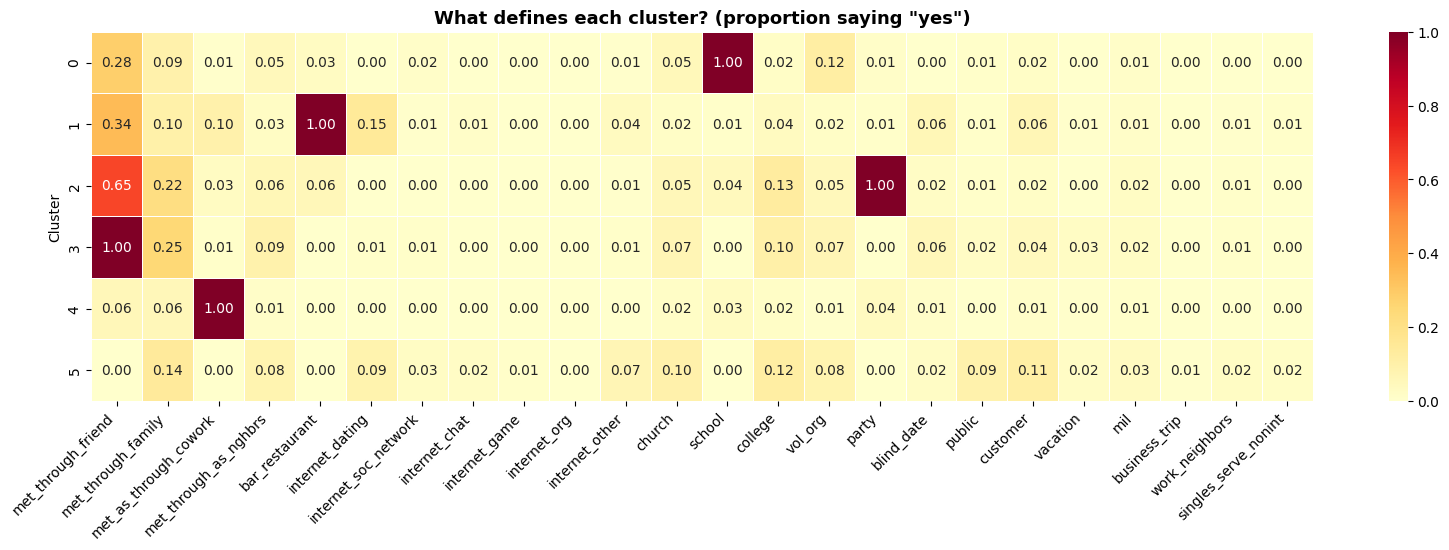

In [6]:
# Average rate of each meeting method per cluster
profiles = df_cluster.groupby("cluster")[how_met_cols].mean()

# Clean up column names for readability
short_names = [c.replace("w1_q24_", "") for c in how_met_cols]
profiles.columns = short_names

# Heatmap
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    profiles,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_title(
    'What defines each cluster? (proportion saying "yes")',
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

Check demographic by cluster

In [7]:
# Demographics by cluster
demo = (
    df_cluster.groupby("cluster")
    .agg(
        avg_age=("w1_ppage", "mean"),
        pct_female=("w1_ppgender", lambda x: (x == 2).mean() * 100),
        pct_married=("w1_married", lambda x: (x == 1).mean() * 100),
        pct_same_sex=("w1_same_sex_couple", lambda x: (x == 1).mean() * 100),
        avg_duration=("w1_relate_duration_in2017_years", "mean"),
        avg_age_met=("w1_age_when_met", "mean"),
        size=("w1_ppage", "count"),
    )
    .round(1)
)

print("Demographic Profile by Cluster")
print("=" * 80)
print(demo.to_string())

Demographic Profile by Cluster
         avg_age  pct_female  pct_married  pct_same_sex  avg_duration  avg_age_met  size
cluster                                                                                 
0           45.5        54.7         64.2           2.8          25.9         16.2   327
1           51.1        47.9         59.1          12.7          20.1         30.2   624
2           48.7        55.5         62.0           7.5          22.4         25.3   292
3           50.1        53.0         68.2           7.1          24.7         24.2   406
4           51.5        53.4         70.8           5.1          22.7         27.8   472
5           49.0        49.4         56.1          11.5          19.3         28.6  1174


These 2 dimensions capture 30.0% of the variation


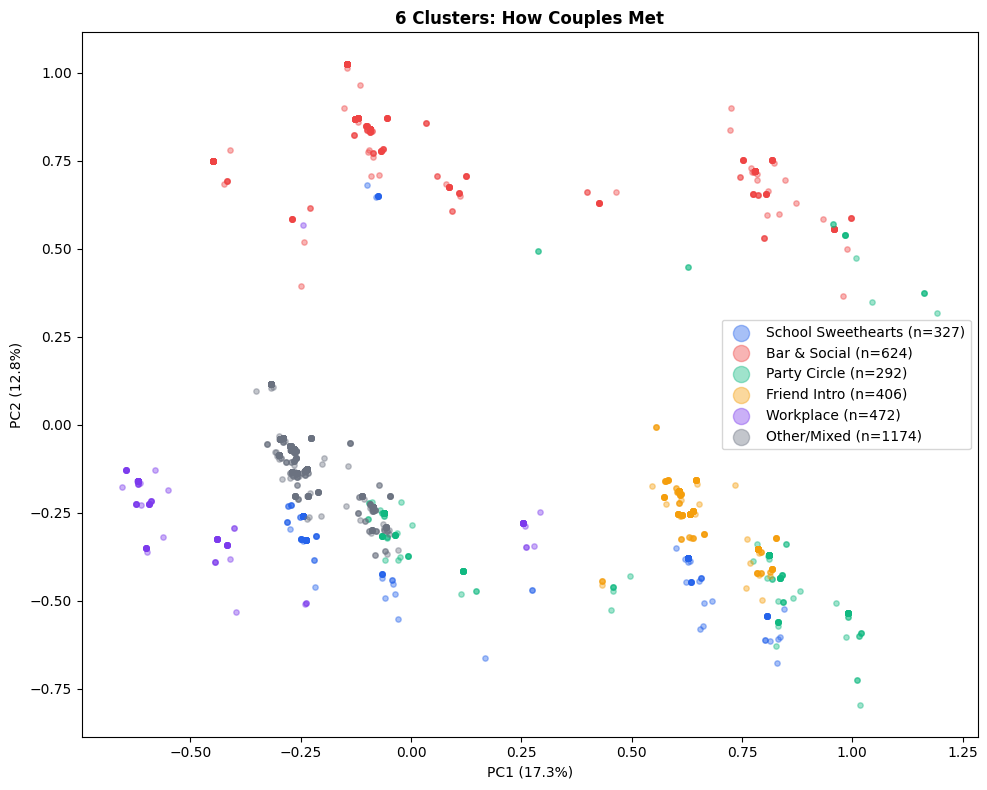

In [8]:
from sklearn.decomposition import PCA

# Reduce 24 features to 2 dimensions
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print(
    f"These 2 dimensions capture {pca.explained_variance_ratio_.sum():.1%} of the variation"
)

# Scatter plot
colors = ["#2563EB", "#EF4444", "#10B981", "#F59E0B", "#7C3AED", "#6B7280"]
cluster_names = [
    "School Sweethearts",
    "Bar & Social",
    "Party Circle",
    "Friend Intro",
    "Workplace",
    "Other/Mixed",
]

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(6):
    mask = df_cluster["cluster"] == i
    ax.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[i],
        label=f"{cluster_names[i]} (n={mask.sum()})",
        alpha=0.4,
        s=15,
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("6 Clusters: How Couples Met", fontweight="bold")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

Relationship outcome by each cluster

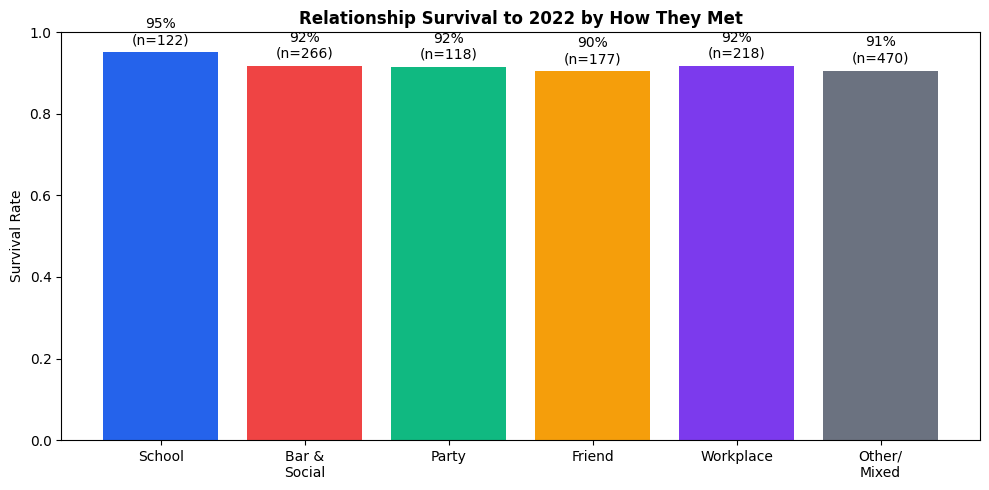

In [ ]:
# Only people who were partnered at W1 and responded to W3
partnered = df_cluster["w1_partnership_status"].isin([1, 2])
in_w3 = df_cluster["w3_combo_weight"].notna()
subset = df_cluster[partnered & in_w3].copy()

# Did the relationship survive?
subset["survived"] = subset["w3_partner_type"].isin([1, 2]).astype(int)

cluster_names = [
    "School",
    "Bar &\nSocial",
    "Party",
    "Friend",
    "Workplace",
    "Other/\nMixed",
]

survival = subset.groupby("cluster")["survived"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2563EB", "#EF4444", "#10B981", "#F59E0B", "#7C3AED", "#6B7280"]
bars = ax.bar(range(6), survival["mean"], color=colors)
ax.set_xticks(range(6))
ax.set_xticklabels(cluster_names)
ax.set_ylabel("Survival Rate")
ax.set_title("Relationship Survival to 2022 by How They Met", fontweight="bold")
ax.set_ylim(0, 1)

# Add labels
for i, (rate, n) in enumerate(zip(survival["mean"], survival["count"])):
    ax.text(i, rate + 0.02, f"{rate:.0%}\n(n={n})", ha="center", fontsize=10)

plt.tight_layout()
plt.show()('')

How you meet your partner doesn't predict whether the relationship survives. All meeting contexts show 90-95% survival rates over 5 years. For OKCupid, this means they can confidently tell users: relationships that start online last just as long as those that start anywhere else 

In [10]:
# Where did online-met people end up?
online = df_cluster[df_cluster["w1_q24_met_online"] == 1]

print(f"Total people who met online: {len(online)}")
print(f"\nWhich clusters are they in?")
online_dist = online["cluster"].value_counts().sort_index()
for i, count in online_dist.items():
    cluster_total = (df_cluster["cluster"] == i).sum()
    print(
        f"  Cluster {i} ({cluster_names[i]}): {count} ({count/len(online):.0%} of online, {count/cluster_total:.0%} of cluster)"
    )

Total people who met online: 402

Which clusters are they in?
  Cluster 0 (School): 7 (2% of online, 2% of cluster)
  Cluster 1 (Bar &
Social): 127 (32% of online, 20% of cluster)
  Cluster 2 (Party): 4 (1% of online, 1% of cluster)
  Cluster 3 (Friend): 14 (3% of online, 3% of cluster)
  Cluster 5 (Other/
Mixed): 250 (62% of online, 21% of cluster)


Online daters don't form a distinct group but they're embedded within other meeting contexts, particularly the Bar & Social cluster. This suggests that for OKCupid's 2017 user base, online dating was a supplement to traditional meeting methods, not a replacement.
Also this data captures relationships existing in 2017 which means many of them startet years earlier.

### Covid effect on clusters

In [11]:
# Covid Variables
covid_w2 = df["w2_coronavirus_effect_combo"].dropna()
print(f"Wave 2 COVID effect on relationship: {len(covid_w2)} respondents")
print(covid_w2.value_counts().sort_index())

print()

# Wave 3
covid_w3 = df["w3_coronavirus_effect_combo"].dropna()
print(f"Wave 3 COVID effect on relationship: {len(covid_w3)} respondents")
print(covid_w3.value_counts().sort_index())

Wave 2 COVID effect on relationship: 1629 respondents
w2_coronavirus_effect_combo
1.0     292
2.0    1248
3.0      89
Name: count, dtype: int64

Wave 3 COVID effect on relationship: 1328 respondents
w3_coronavirus_effect_combo
1.0     239
2.0    1017
3.0      72
Name: count, dtype: int64


In [12]:
# Labels
print("Wave 2 COVID labels:")
print(labels.get("w2_coronavirus_effect_combo"))

print("\nWave 3 COVID labels:")
print(labels.get("w3_coronavirus_effect_combo"))

Wave 2 COVID labels:
{1: 'better rel than before', 2: 'no change', 3: 'worse rel than before'}

Wave 3 COVID labels:
{-1: 'Refused', 1: 'Our relationship is better than before', 2: 'No change', 3: 'Our relationship is worse than before'}


##### Connect covid data with clusters

In [13]:
# People with both cluster and COVID data
covid = df_cluster[df_cluster["w2_coronavirus_effect_combo"].notna()].copy()

covid["covid_label"] = covid["w2_coronavirus_effect_combo"].map(
    {1.0: "Better", 2.0: "No change", 3.0: "Worse"}
)

print(f"People with both cluster and COVID data: {len(covid)}")
print(f"\nBy cluster:")
print(covid["cluster"].value_counts().sort_index())

People with both cluster and COVID data: 1590

By cluster:
cluster
0    153
1    315
2    143
3    212
4    244
5    523
Name: count, dtype: int64


Covid breakdown by cluster

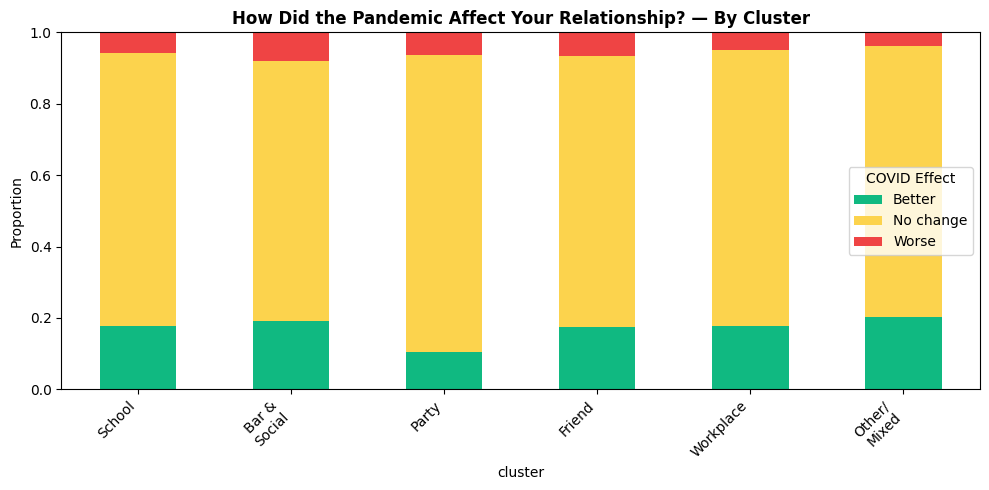

covid_label  Better  No change  Worse
cluster                              
0             0.176      0.765  0.059
1             0.190      0.730  0.079
2             0.105      0.832  0.063
3             0.175      0.759  0.066
4             0.176      0.775  0.049
5             0.203      0.759  0.038


In [14]:
# COVID effect breakdown by cluster
covid_by_cluster = pd.crosstab(
    covid["cluster"], covid["covid_label"], normalize="index"
)
covid_by_cluster = covid_by_cluster[["Better", "No change", "Worse"]]

fig, ax = plt.subplots(figsize=(10, 5))
covid_by_cluster.plot.bar(stacked=True, ax=ax, color=["#10B981", "#FCD34D", "#EF4444"])
ax.set_xticklabels(cluster_names, rotation=45, ha="right")
ax.set_ylabel("Proportion")
ax.set_title(
    "How Did the Pandemic Affect Your Relationship? — By Cluster", fontweight="bold"
)
ax.legend(title="COVID Effect")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(covid_by_cluster.round(3))

In [15]:
from scipy.stats import chi2_contingency

# Chi-square test: is there a real association between cluster and COVID effect?
contingency = pd.crosstab(covid["cluster"], covid["covid_label"])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square test: cluster × COVID effect")
print(f"  Chi-square statistic: {chi2:.2f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Degrees of freedom: {dof}")

if p_value < 0.05:
    print(f"\n→ Statistically significant (p < 0.05)")
    print(f"  How couples met IS associated with how COVID affected their relationship")
else:
    print(f"\n→ NOT statistically significant (p >= 0.05)")
    print(
        f"  We cannot conclude that meeting method affected COVID impact on relationships"
    )

Chi-square test: cluster × COVID effect
  Chi-square statistic: 14.33
  p-value: 0.1585
  Degrees of freedom: 10

→ NOT statistically significant (p >= 0.05)
  We cannot conclude that meeting method affected COVID impact on relationships


COVID finding: Pandemic affected all clusters equally (chi-square, p=0.16) 

##### What W1 factors predict whether a couple is still together in 2022?

In [16]:
# People who were partnered at W1 and responded to W3
partnered_w1 = df_cluster["w1_partnership_status"].isin([1, 2])
in_w3 = df_cluster["w3_combo_weight"].notna()
model_df = df_cluster[partnered_w1 & in_w3].copy()

# Target: is the couple still together in 2022?
model_df["still_together"] = model_df["w3_partner_type"].isin([1, 2]).astype(int)

print(f"Sample size: {len(model_df)}")
print(f"Still together: {model_df['still_together'].mean():.1%}")
print(f"Broke up:       {1 - model_df['still_together'].mean():.1%}")


Sample size: 1371
Still together: 91.5%
Broke up:       8.5%


In [17]:
# Select features for the model
features = model_df[
    [
        # Demographics
        "w1_ppage",
        "w1_ppgender",
        "w1_ppeducat",
        "w1_ppethm",
        "w1_ppincimp",
        "w1_PPREG4",
        # Relationship characteristics
        "w1_partnership_status",
        "w1_same_sex_couple",
        "w1_age_when_met",
        "w1_relate_duration_in2017_years",
        "w1_q34",
        # How they met
        "w1_q24_met_online",
        "w1_q24_met_through_friend",
        "w1_q24_bar_restaurant",
        "w1_q24_met_as_through_cowork",
        "w1_q24_church",
        # Cluster
        "cluster",
    ]
].copy()

target = model_df["still_together"]

print(f"Features: {features.shape[1]} columns, {len(features)} rows")
print(f"Target: {target.mean():.1%} still together")

Features: 17 columns, 1371 rows
Target: 91.5% still together


In [18]:
# Clean and split the data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Drop rows with missing values
clean_mask = features.notna().all(axis=1)
X = features[clean_mask]
y = target[clean_mask]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")
print(f"Breakups in test: {(y_test == 0).sum()}")


Train: 1065 rows
Test:  267 rows
Breakups in test: 23


In [19]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",  # This tells the model to pay extra attention to breakups
)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("=== Confusion Matrix ===")
print(f"                  Predicted Together  Predicted Broke Up")
cm = confusion_matrix(y_test, y_pred)
print(f"Actually Together:       {cm[1][1]}                {cm[1][0]}")
print(f"Actually Broke Up:       {cm[0][1]}                {cm[0][0]}")

print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Broke Up", "Together"]))

print(f"\nBaseline accuracy (always predict together): {y_test.mean():.1%}")
print(f"Model accuracy: {(y_pred == y_test).mean():.1%}")

=== Confusion Matrix ===
                  Predicted Together  Predicted Broke Up
Actually Together:       242                2
Actually Broke Up:       21                2

=== Classification Report ===
              precision    recall  f1-score   support

    Broke Up       0.50      0.09      0.15        23
    Together       0.92      0.99      0.95       244

    accuracy                           0.91       267
   macro avg       0.71      0.54      0.55       267
weighted avg       0.88      0.91      0.89       267


Baseline accuracy (always predict together): 91.4%
Model accuracy: 91.4%


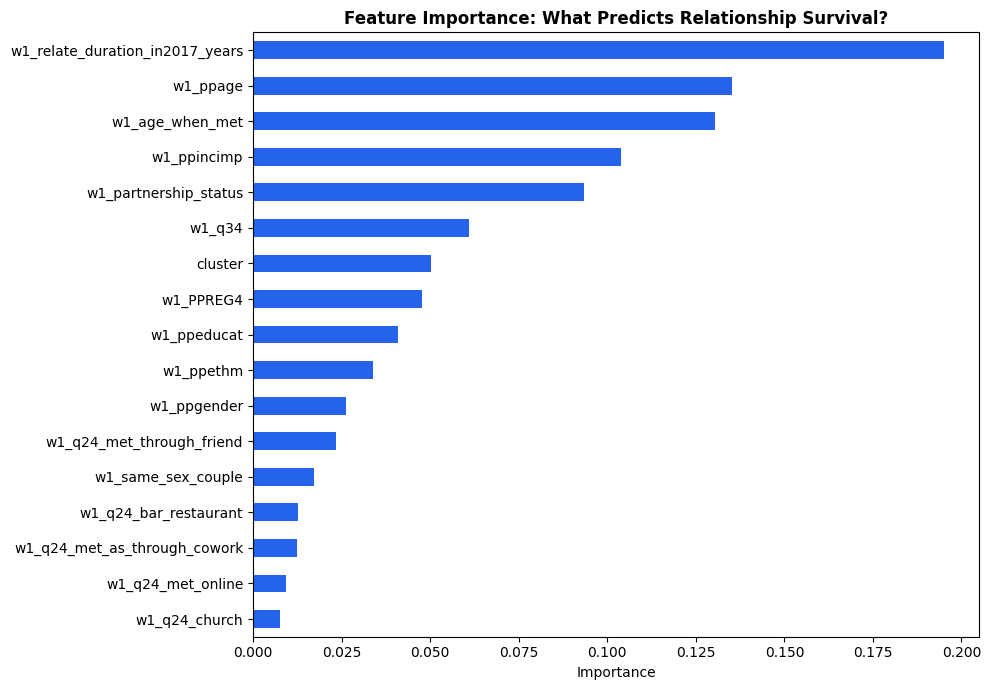

Top 5 most important features:
  w1_relate_duration_in2017_years: 0.195
  w1_ppage: 0.135
  w1_age_when_met: 0.130
  w1_ppincimp: 0.104
  w1_partnership_status: 0.093


In [20]:
# Feature importance — what did the model pay attention to?
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot.barh(ax=ax, color="#2563EB")
ax.set_title(
    "Feature Importance: What Predicts Relationship Survival?", fontweight="bold"
)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for feat, imp in importance.nlargest(5).items():
    print(f"  {feat}: {imp:.3f}")

- What predicts whether a couple stays together? Not how they met — but how long they've been together, their age, income, and whether they're married. For OKCupid, this means the platform's job is to help people START relationships. How the relationship starts doesn't determine its fate — what matters is what happens after.

## Part 3 — Conclusions and Recommendations

### Key Findings

**1. How Americans Meet Their Partners (Clustering)**

We identified 6 distinct meeting profiles among 3,295 partnered respondents:
- **School Sweethearts** (10%) — met as teenagers, longest relationships (26 years avg)
- **Bar & Social** (19%) — social venues, highest same-sex couple rate (13%)
- **Party Circle** (9%) — private parties, strongly connected to friend/family networks
- **Friend Introductions** (12%) — classic "set up by a friend," high marriage rate (68%)
- **Workplace** (14%) — highest marriage rate (71%), very stable
- **Other/Mixed** (36%) — no dominant channel, most diverse group

Online daters did not form their own cluster — they were absorbed into Bar & Social (32%) and Other/Mixed (62%), suggesting online dating in 2017 was a supplement to traditional meeting methods, not a separate category.

**2. The Pandemic Was an Equal-Opportunity Stressor**

We tested whether COVID affected couples differently depending on how they met. It did not (chi-square test, p=0.16). Across all clusters, ~76% reported no change, ~18% said better, ~6% said worse. How you met your partner did not make your relationship more or less vulnerable to the pandemic.

**3. What Actually Predicts Relationship Survival**

We built a classification model to predict which couples stay together from 2017 to 2022. The model struggled to beat the 91.5% baseline, but the feature importance analysis revealed a clear hierarchy:

- **What matters most:** relationship duration, age, age when met, income, marital status
- **What matters somewhat:** relationship quality, cluster/meeting context, region, education
- **What barely matters:** how they met (online, friends, bar, church, work — all <0.02 importance)

The strongest predictor is simply how long the couple has already been together. Meeting method has almost no predictive power.

### Recommendations for OKCupid

**1. "How you meet doesn't define your relationship" — use this in marketing.**
Our data shows that couples who met online have virtually identical survival rates (90-95%) to couples who met through friends, at work, or at church. OKCupid can confidently tell users that relationships started on their platform are just as durable as any other. This is backed by longitudinal Stanford data tracking real couples over 5 years.

**2. Focus on relationship starters, not relationship predictors.**
Since meeting method doesn't predict survival, OKCupid's value isn't in matching people who will "last forever" — it's in creating opportunities for connection that wouldn't otherwise exist. The platform should optimize for first meetings, not try to predict compatibility.

**3. Target underrepresented demographics.**
Our Workplace and Friend Intro clusters have the highest marriage rates but the lowest online presence. These are people who find partners through existing social structures. OKCupid could reach them by marketing to people who have recently changed jobs, moved cities, or left a social community — moments when traditional meeting channels break down.

**4. Online dating is a channel, not a tribe.**
Online daters don't have a distinct demographic or relationship profile — they look like everyone else. This means OKCupid shouldn't pigeonhole its users. The platform should feel like a natural extension of social life, not a separate "online dating world."

### Limitations

- **Survivorship bias:** couples who broke up before 2017 aren't in the data. We only see relationships that already lasted.
- **Attrition:** 51% of respondents dropped out by Wave 3, and dropout was not random — younger people, less educated, and unmarried partners left more. This inflates survival rates.
- **Historical data:** most relationships in this dataset started years before 2017. The online dating landscape has changed dramatically since then — Tinder launched in 2012, and app usage has grown exponentially. Our 5.9% internet dating rate likely underestimates current rates.
- **Correlation ≠ causation:** relationship duration predicts survival, but that's partly tautological — longer relationships have survived longer by definition. Income predicts survival, but we can't say money causes relationships to last.
- **What we'd need:** data from relationships started in 2020+ would better reflect modern online dating. Access to which specific app was used would let OKCupid compare itself to competitors.

In [21]:
# Find variables with good coverage and balanced distributions
# We want: >1000 non-null values, and no single value above 80%

print("POTENTIAL TARGET VARIABLES")
print("=" * 70)

for col in df.columns:
    non_null = df[col].notna().sum()
    if non_null < 1000:
        continue

    vals = df[col].dropna()
    if vals.nunique() < 2 or vals.nunique() > 20:  # skip continuous and single-value
        continue

    top_pct = vals.value_counts(normalize=True).iloc[0]
    if top_pct > 0.80:  # skip heavily imbalanced
        continue

    print(f"\n{col} (n={non_null}, {vals.nunique()} categories)")
    print(f"  {vals.value_counts(normalize=True).round(3).to_dict()}")

POTENTIAL TARGET VARIABLES

w3_xpartner_type (n=3510, 4 categories)
  {1.0: 0.591, 2.0: 0.199, 3.0: 0.18, 4.0: 0.029}

w3_xlast_contact_year (n=3510, 2 categories)
  {2020.0: 0.6, 2017.0: 0.4}

w3_xlast_contact_mo (n=3510, 4 categories)
  {9.0: 0.577, 7.0: 0.399, 10.0: 0.023, 8.0: 0.0}

w3_ppagecat (n=1722, 7 categories)
  {5.0: 0.246, 6.0: 0.206, 4.0: 0.142, 3.0: 0.135, 2.0: 0.132, 7.0: 0.122, 1.0: 0.017}

w3_ppagect4 (n=1722, 4 categories)
  {4.0: 0.457, 3.0: 0.259, 2.0: 0.233, 1.0: 0.051}

w3_ppeduc (n=1722, 14 categories)
  {9.0: 0.239, 12.0: 0.238, 10.0: 0.17, 13.0: 0.141, 11.0: 0.107, 14.0: 0.052, 7.0: 0.014, 6.0: 0.012, 8.0: 0.01, 4.0: 0.006, 5.0: 0.005, 3.0: 0.003, 1.0: 0.002, 2.0: 0.002}

w3_ppeducat (n=1722, 4 categories)
  {4.0: 0.431, 3.0: 0.277, 2.0: 0.239, 1.0: 0.053}

w3_ppethm (n=1722, 5 categories)
  {1.0: 0.755, 4.0: 0.105, 2.0: 0.084, 3.0: 0.034, 5.0: 0.022}

w3_ppgender (n=1722, 2 categories)
  {1.0: 0.551, 2.0: 0.449}

w3_pphhsize (n=1722, 10 categories)
  {2.0: 0.